### 1. Wczytanie bibliotek i załadowanie danych

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from scipy import stats
from statsmodels.stats.stattools import durbin_watson
from kagglehub import KaggleDatasetAdapter
import kagglehub

file_path = "HR Employee Attrition.csv"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "whenamancodes/hr-employee-attrition",
  file_path,
)

### 2. Przygotowanie danych

In [21]:
# Wybranie cechy którą bedziemy predykować
target = 'MonthlyIncome'
X = df.drop(columns=[target])
y = df[target]

In [22]:
# Rozróżnienie kolumn numerycznych i kategorycznych
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

In [23]:
# Pipeline preprocessingu (OneHot dla kategorii)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

In [24]:
# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Transformacja danych
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [26]:
# nazwy cech po transformacji
try:
    cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
    feature_names = np.r_[numeric_features, cat_names]
except:
    feature_names = [f"Feature_{i}" for i in range(X_train_processed.shape[1])]

### 3. Porównanie regresjii liniowej, Ridge

In [27]:
lin_reg = LinearRegression()
ridge_reg = Ridge(alpha=10.0) # alpha to siła regularyzacji

lin_reg.fit(X_train_processed, y_train)
ridge_reg.fit(X_train_processed, y_train)

# Predykcje
y_pred_lin = lin_reg.predict(X_test_processed)
y_pred_ridge = ridge_reg.predict(X_test_processed)

# Wyniki
r2_lin = r2_score(y_test, y_pred_lin)
r2_ridge = r2_score(y_test, y_pred_ridge)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"--- WYNIKI ---")
print(f"Linear Regression: R2 = {r2_lin:.4f}, RMSE = {rmse_lin:.2f}")
print(f"Ridge Regression:  R2 = {r2_ridge:.4f}, RMSE = {rmse_ridge:.2f}")

--- WYNIKI ---
Linear Regression: R2 = 0.9378, RMSE = 1165.71
Ridge Regression:  R2 = 0.9355, RMSE = 1187.37


### 3.1 Siec neuronowa

Trening na w pełni zeskalowanych danych...
Epoch 20/200, Loss: 0.0651
Epoch 40/200, Loss: 0.0502
Epoch 60/200, Loss: 0.0473
Epoch 80/200, Loss: 0.0450
Epoch 100/200, Loss: 0.0416
Epoch 120/200, Loss: 0.0462
Epoch 140/200, Loss: 0.0431
Epoch 160/200, Loss: 0.0375
Epoch 180/200, Loss: 0.0397
Epoch 200/200, Loss: 0.0369

Sieć neuronowa MAE: 0.203

--- WYNIKI Sieci neuronowej ---
RMSE: 1282.22
R2:   0.9248


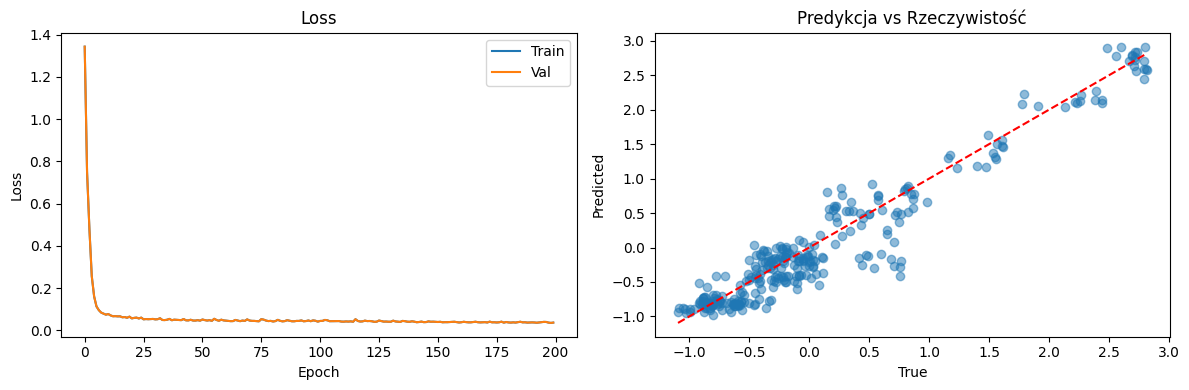

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

X_train_np = X_train_processed.toarray() if hasattr(X_train_processed, 'toarray') else X_train_processed
X_test_np = X_test_processed.toarray() if hasattr(X_test_processed, 'toarray') else X_test_processed

scaler_X = StandardScaler(with_mean=False) 
X_train_scaled = scaler_X.fit_transform(X_train_np)
X_test_scaled = scaler_X.transform(X_test_np)


scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()


X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_scaled).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test_scaled).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

class RegressionNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

input_dim = X_train_tensor.shape[1]
model = RegressionNN(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 200
train_losses = []

print("Trening na w pełni zeskalowanych danych...")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    train_losses.append(epoch_loss / len(train_loader))
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {train_losses[-1]:.4f}")

# --- 4. WYNIKI (ODWRACANIE SKALOWANIA) ---
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    test_mae = torch.mean(torch.abs(predictions - y_test_tensor))
    print(f"\nSieć neuronowa MAE: {test_mae:.3f}")


predictions_real = scaler_y.inverse_transform(predictions)
y_test_real = y_test.values.reshape(-1, 1)

rmse = np.sqrt(mean_squared_error(y_test_real, predictions_real))
r2 = r2_score(y_test_real, predictions_real)

print(f"\n--- WYNIKI Sieci neuronowej ---")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train')
plt.plot(train_losses, label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.scatter(y_test_scaled, predictions.numpy(), alpha=0.5)
plt.plot([y_test_scaled.min(), y_test_scaled.max()],
         [y_test_scaled.min(), y_test_scaled.max()], 'r--')
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Predykcja vs Rzeczywistość')
plt.tight_layout()
plt.show()

### 4. Analiza ważnosci Cech RIDGE

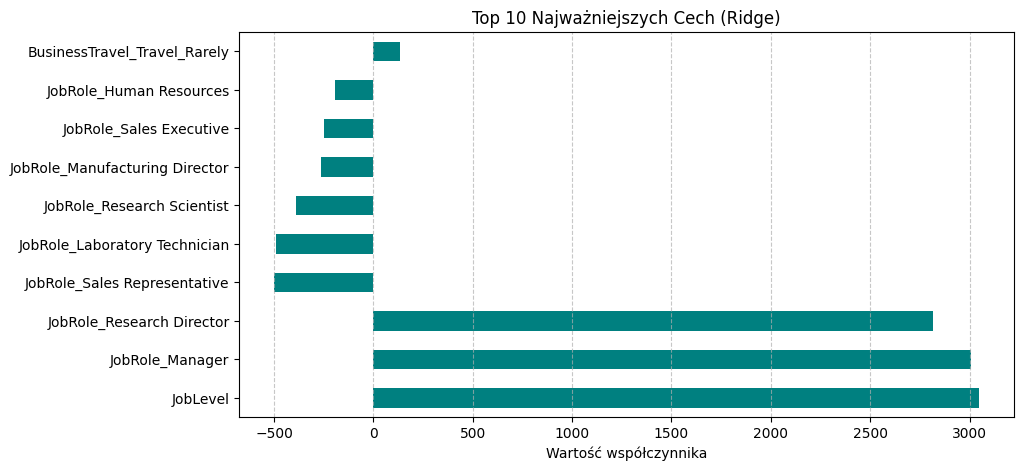

In [29]:
coefs = pd.Series(ridge_reg.coef_, index=feature_names)
top_features = coefs.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
coefs[top_features.index].plot(kind='barh', color='teal')
plt.title("Top 10 Najważniejszych Cech (Ridge)")
plt.xlabel("Wartość współczynnika")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


### 5.1 Analiza reszt regresja liniowa


--- ANALIZA RESZT : REGRESJA LINIOWA---
Test Shapiro-Wilka (Normalność): p-value = 2.5949e-05
  -> Reszty NIE mają rozkładu normalnego (p < 0.05).
Test Durbin-Watson (Autokorelacja): 2.13
  (Wartość bliska 2.0 oznacza brak autokorelacji. < 1.5 to korelacja dodatnia)


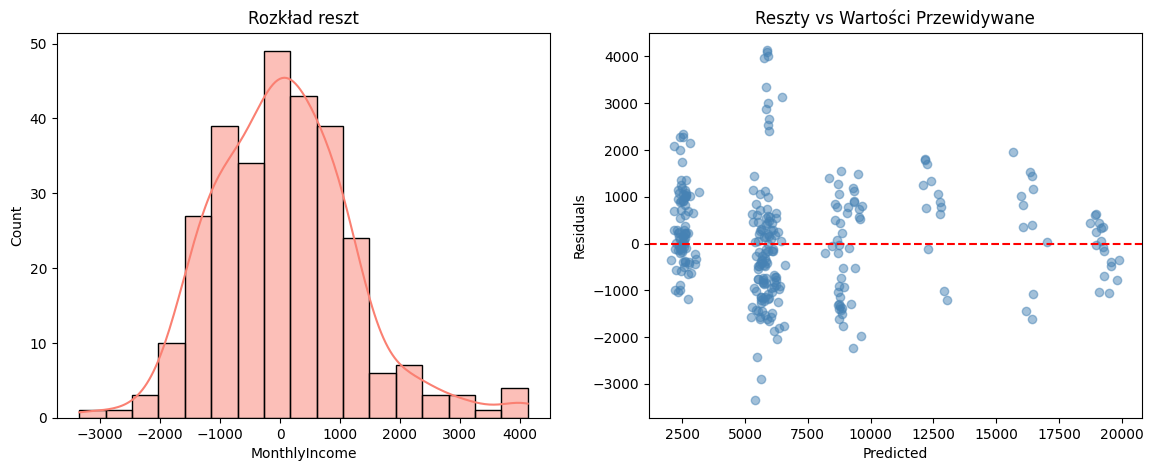

In [30]:
residuals = y_test - y_pred_lin

# Test normalności (Shapiro-Wilk)
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"\n--- ANALIZA RESZT : REGRESJA LINIOWA---")
print(f"Test Shapiro-Wilka (Normalność): p-value = {shapiro_p:.4e}")
if shapiro_p > 0.05:
    print("  -> Nie ma podstaw do odrzucenia hipotezy o normalności reszt (rozkład normalny).")
else:
    print("  -> Reszty NIE mają rozkładu normalnego (p < 0.05).")

# Test autokorelacji
dw_stat = durbin_watson(residuals)
print(f"Test Durbin-Watson (Autokorelacja): {dw_stat:.2f}")
print("  (Wartość bliska 2.0 oznacza brak autokorelacji. < 1.5 to korelacja dodatnia)")

# Wykresy reszt
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(residuals, kde=True, ax=ax[0], color='salmon')
ax[0].set_title("Rozkład reszt")
ax[1].scatter(y_pred_lin, residuals, alpha=0.5, color='steelblue')
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title("Reszty vs Wartości Przewidywane")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Residuals")
plt.show()

### 5.2 Analiza reszt Ridge


--- ANALIZA RESZT : RIDGE---
Test Shapiro-Wilka (Normalność): p-value = 3.9605e-05
  -> Reszty NIE mają rozkładu normalnego (p < 0.05).
Test Durbin-Watson (Autokorelacja): 2.12
  (Wartość bliska 2.0 oznacza brak autokorelacji. < 1.5 to korelacja dodatnia)


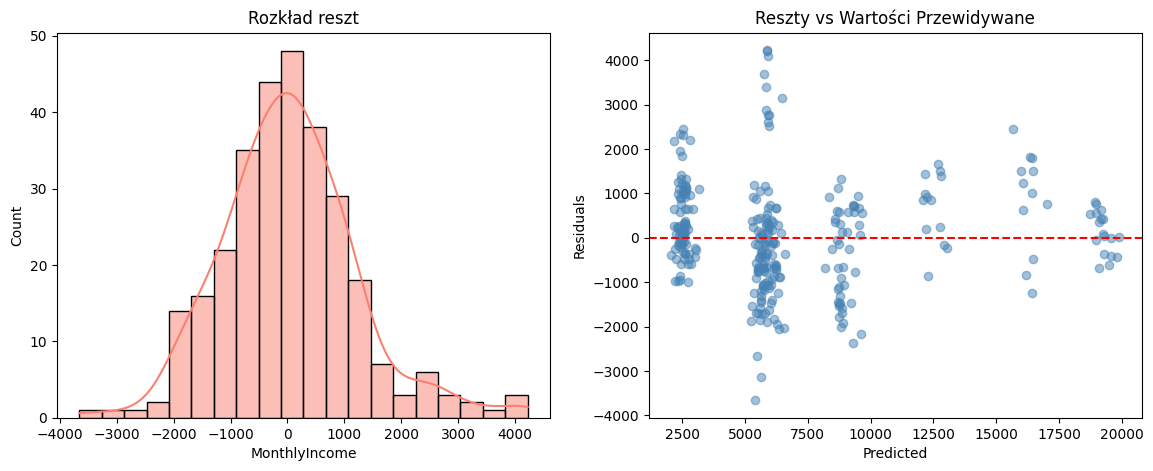

In [ ]:
residuals = y_test - y_pred_ridge

shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"\n--- ANALIZA RESZT : RIDGE---")
print(f"Test Shapiro-Wilka (Normalność): p-value = {shapiro_p:.4e}")
if shapiro_p > 0.05:
    print("  -> Nie ma podstaw do odrzucenia hipotezy o normalności reszt (rozkład normalny).")
else:
    print("  -> Reszty NIE mają rozkładu normalnego (p < 0.05).")


dw_stat = durbin_watson(residuals)
print(f"Test Durbin-Watson (Autokorelacja): {dw_stat:.2f}")
print("  (Wartość bliska 2.0 oznacza brak autokorelacji. < 1.5 to korelacja dodatnia)")

# Wykresy reszt
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(residuals, kde=True, ax=ax[0], color='salmon')
ax[0].set_title("Rozkład reszt")
ax[1].scatter(y_pred_lin, residuals, alpha=0.5, color='steelblue')
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title("Reszty vs Wartości Przewidywane")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Residuals")
plt.show()

### 6. Różnice wyników w zależnosci od saklowanych danych

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

ridge_reg_scaled = Ridge(alpha=10.0)
ridge_reg_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = ridge_reg_scaled.predict(X_test_scaled)


lin_reg_scaled = LinearRegression()
lin_reg_scaled.fit(X_train_scaled, y_train)
y_pred_scaled_lin = lin_reg_scaled.predict(X_test_scaled)


ridge_no_scale_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_scale_rmse = np.sqrt(mean_squared_error(y_test, y_pred_scaled))

lin_no_scale_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lin))
lin_scale_rmse = np.sqrt(mean_squared_error(y_test, y_pred_scaled_lin))

r2_ridge = r2_score(y_test, y_pred_ridge)
r2_ridge_scale = r2_score(y_test, y_pred_scaled)

r2_lin = r2_score(y_test, y_pred_lin)
r2_lin_scale = r2_score(y_test, y_pred_scaled_lin)


print(f"\n--- WPŁYW SKALOWANIA (RIDGE) ---")
print(f"Bez skalowania: RMSE = {ridge_no_scale_rmse:.2f} R2 ={r2_ridge:.4f}")
print(f"Zeskalowane:    RMSE = {ridge_scale_rmse:.2f} R2 ={r2_ridge_scale:.4f}")
print("###################################################################")
print(f"\n--- WPŁYW SKALOWANIA (REGRESJA LINIOWA) ---")
print(f"Bez skalowania: RMSE = {lin_no_scale_rmse:.2f} R2 ={r2_lin:.4f}")
print(f"Zeskalowane:    RMSE = {lin_scale_rmse:.2f} R2 ={r2_lin_scale:.4f}")


--- WPŁYW SKALOWANIA (RIDGE) ---
Bez skalowania: RMSE = 1187.37 R2 =0.9355
Zeskalowane:    RMSE = 1160.21 R2 =0.9384
###################################################################

--- WPŁYW SKALOWANIA (REGRESJA LINIOWA) ---
Bez skalowania: RMSE = 1165.71 R2 =0.9378
Zeskalowane:    RMSE = 1165.71 R2 =0.9378


### 7. Wizualizacja wyników

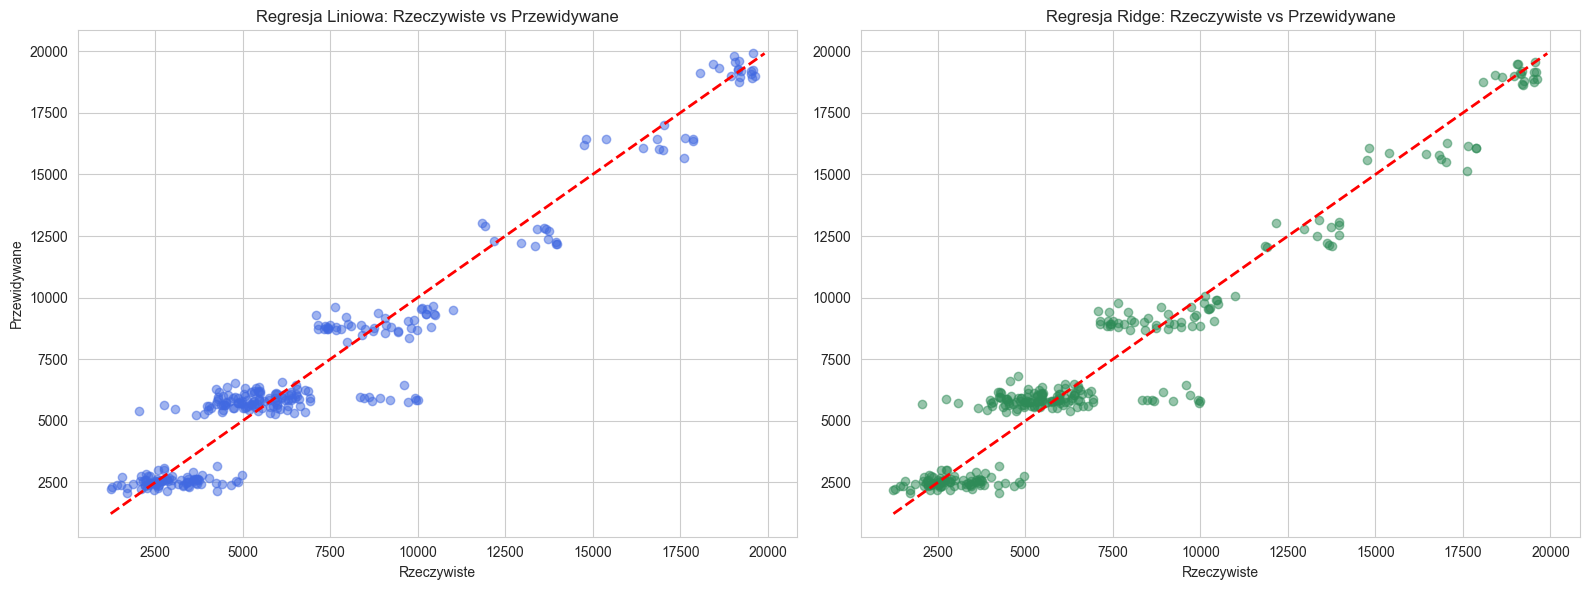

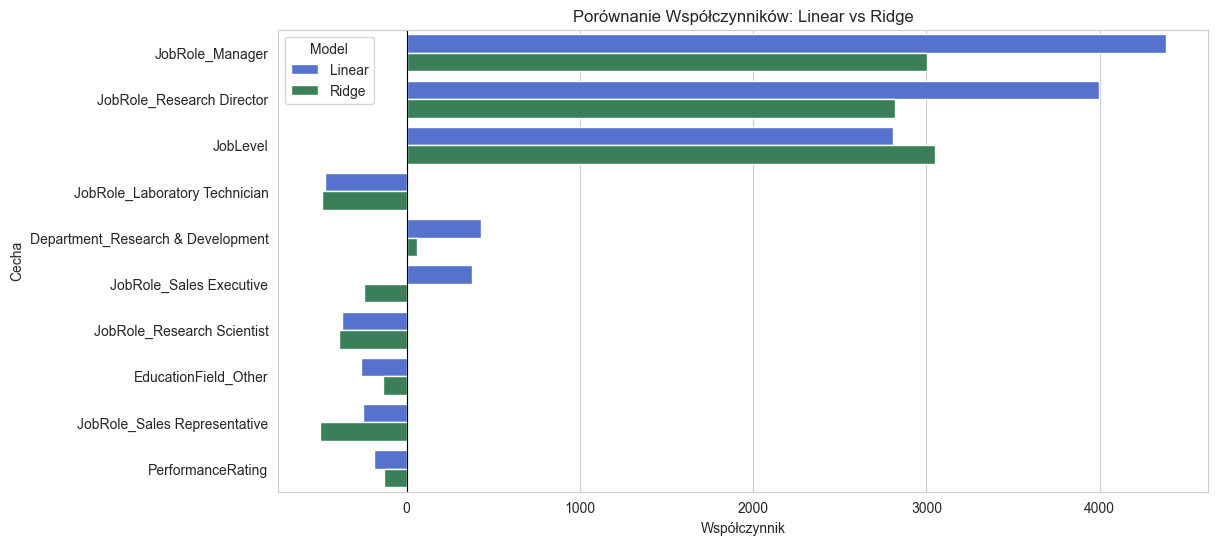

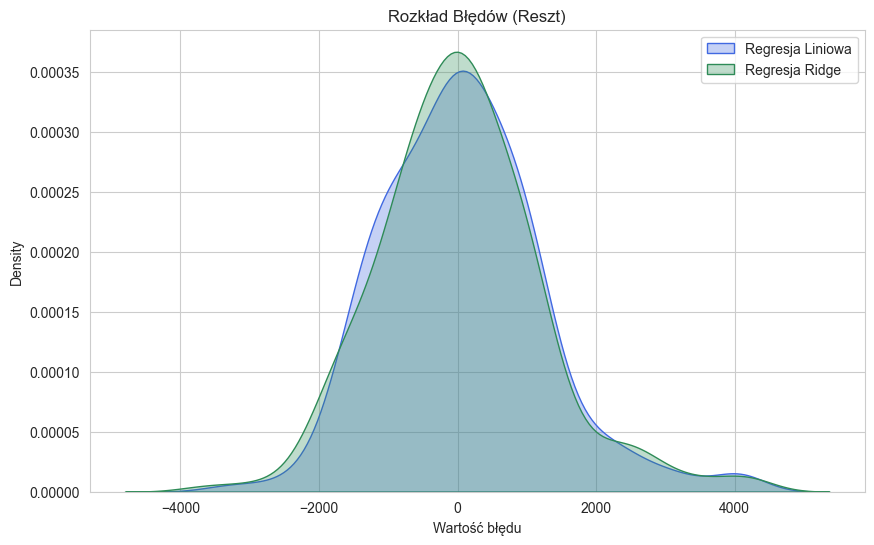

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
min_val = min(y_test.min(), y_pred_lin.min(), y_pred_ridge.min())
max_val = max(y_test.max(), y_pred_lin.max(), y_pred_ridge.max())

# Liniowa
axes[0].scatter(y_test, y_pred_lin, alpha=0.5, color='royalblue')
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
axes[0].set_title('Regresja Liniowa: Rzeczywiste vs Przewidywane')
axes[0].set_xlabel('Rzeczywiste')
axes[0].set_ylabel('Przewidywane')

# Ridge
axes[1].scatter(y_test, y_pred_ridge, alpha=0.5, color='seagreen')
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
axes[1].set_title('Regresja Ridge: Rzeczywiste vs Przewidywane')
axes[1].set_xlabel('Rzeczywiste')

plt.tight_layout()
plt.show()

df_coefs = pd.DataFrame({
    'Cecha': feature_names,
    'Linear': lin_reg.coef_,
    'Ridge': ridge_reg.coef_
})
df_coefs['abs_val'] = df_coefs['Linear'].abs()
df_top_coefs = df_coefs.sort_values('abs_val', ascending=False).head(10)
df_melted = df_top_coefs.melt(id_vars='Cecha', value_vars=['Linear', 'Ridge'], var_name='Model', value_name='Współczynnik')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Współczynnik', y='Cecha', hue='Model', palette=['royalblue', 'seagreen'])
plt.title('Porównanie Współczynników: Linear vs Ridge')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

residuals_lin = y_test - y_pred_lin
residuals_ridge = y_test - y_pred_ridge

plt.figure(figsize=(10, 6))
sns.kdeplot(residuals_lin, label='Regresja Liniowa', fill=True, color='royalblue', alpha=0.3)
sns.kdeplot(residuals_ridge, label='Regresja Ridge', fill=True, color='seagreen', alpha=0.3)
plt.title('Rozkład Błędów (Reszt)')
plt.xlabel('Wartość błędu')
plt.legend()
plt.show()

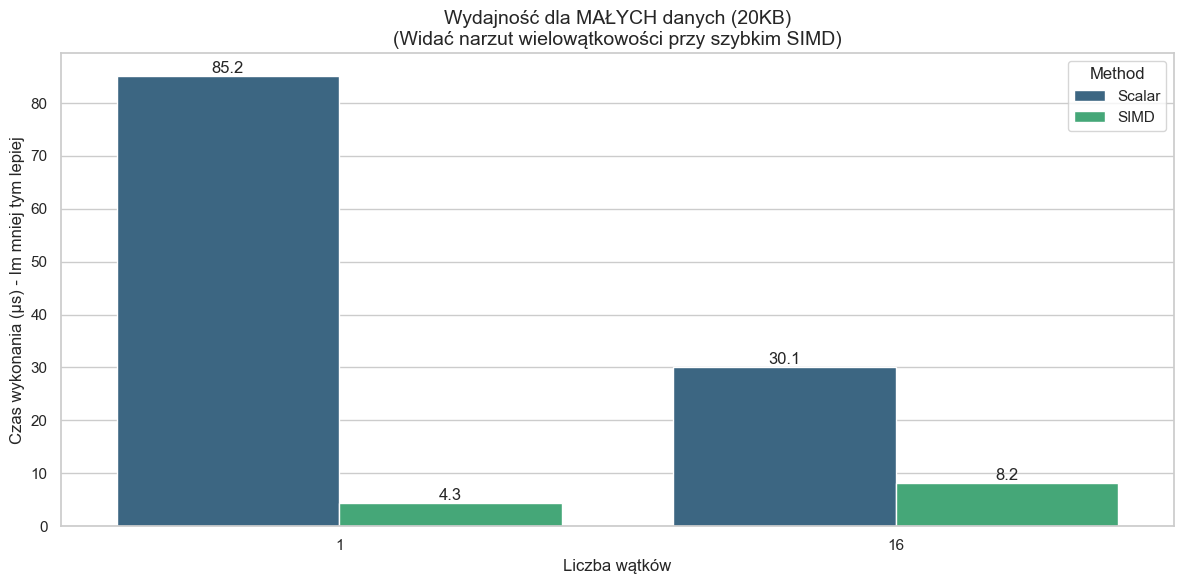

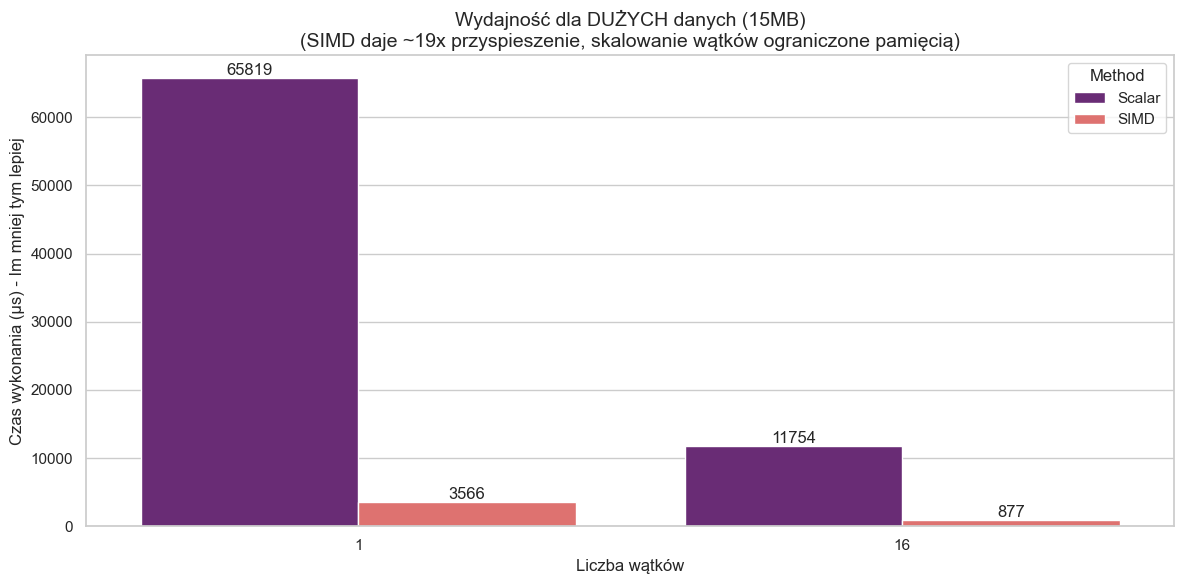

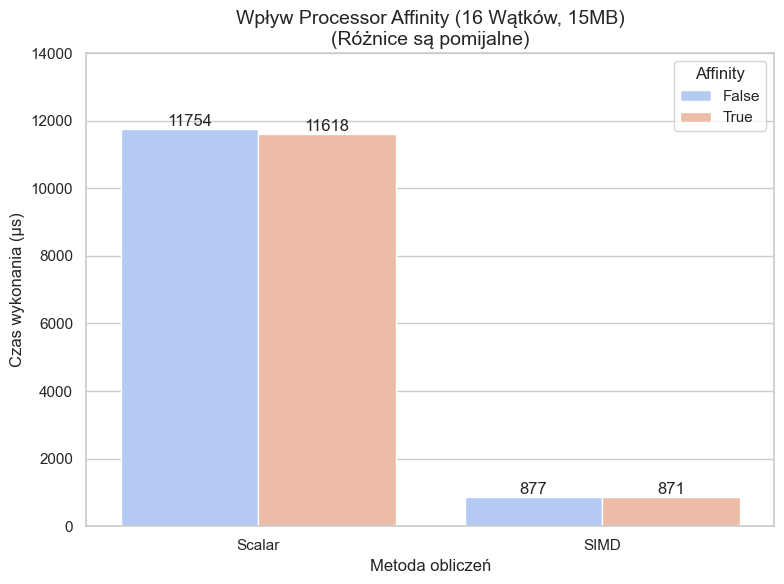

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. PRZYGOTOWANIE DANYCH (Przepisane z Twojej tabeli)
# Konwertujemy wszystkie czasy na mikrosekundy (us) dla spójności.
data = [
    # Małe dane (20 KB)
    {"Method": "Scalar", "Size": "Small (20KB)", "Threads": 1,  "Affinity": False, "Time_us": 85.176},
    {"Method": "SIMD",   "Size": "Small (20KB)", "Threads": 1,  "Affinity": False, "Time_us": 4.291},
    {"Method": "Scalar", "Size": "Small (20KB)", "Threads": 16, "Affinity": False, "Time_us": 30.051},
    {"Method": "SIMD",   "Size": "Small (20KB)", "Threads": 16, "Affinity": False, "Time_us": 8.177},
    
    # Duże dane (15 MB) - Affinity False (Domyślne)
    {"Method": "Scalar", "Size": "Large (15MB)", "Threads": 1,  "Affinity": False, "Time_us": 65818.90},
    {"Method": "SIMD",   "Size": "Large (15MB)", "Threads": 1,  "Affinity": False, "Time_us": 3566.19},
    {"Method": "Scalar", "Size": "Large (15MB)", "Threads": 16, "Affinity": False, "Time_us": 11753.50},
    {"Method": "SIMD",   "Size": "Large (15MB)", "Threads": 16, "Affinity": False, "Time_us": 876.69},

    # Dane do porównania Affinity (Tylko dla Large, 16 Threads gdzie powinno to mieć znaczenie)
    {"Method": "Scalar", "Size": "Large (15MB)", "Threads": 16, "Affinity": True,  "Time_us": 11617.62},
    {"Method": "SIMD",   "Size": "Large (15MB)", "Threads": 16, "Affinity": True,  "Time_us": 870.98},
]

df = pd.DataFrame(data)

# Ustawienie stylu wykresów
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- WYKRES 1: MAŁE DANE (20KB) ---
# Pokazuje problem narzutu wątków przy SIMD
plt.figure()
df_small = df[(df["Size"] == "Small (20KB)") & (df["Affinity"] == False)]

chart1 = sns.barplot(
    data=df_small, 
    x="Threads", 
    y="Time_us", 
    hue="Method",
    palette="viridis"
)

plt.title("Wydajność dla MAŁYCH danych (20KB)\n", fontsize=14)
plt.ylabel("Czas wykonania (µs) - Im mniej tym lepiej")
plt.xlabel("Liczba wątków")
plt.bar_label(chart1.containers[0], fmt='%.1f')
plt.bar_label(chart1.containers[1], fmt='%.1f')
plt.tight_layout()
plt.show()


# --- WYKRES 2: DUŻE DANE (15MB) ---
# Pokazuje ogromną przewagę SIMD i skalowanie wątków
plt.figure()
df_large = df[(df["Size"] == "Large (15MB)") & (df["Affinity"] == False)]

chart2 = sns.barplot(
    data=df_large, 
    x="Threads", 
    y="Time_us", 
    hue="Method",
    palette="magma"
)

plt.title("Wydajność dla DUŻYCH danych (15MB)\n(SIMD daje ~19x przyspieszenie, skalowanie wątków ograniczone pamięcią)", fontsize=14)
plt.ylabel("Czas wykonania (µs) - Im mniej tym lepiej")
plt.xlabel("Liczba wątków")
# Dodanie etykiet wartości nad słupkami
for container in chart2.containers:
    chart2.bar_label(container, fmt='%.0f')
plt.tight_layout()
plt.show()


# --- WYKRES 3: WPŁYW AFFINITY (Large Data, 16 Threads) ---
# Pokazuje brak istotnych różnic
plt.figure(figsize=(8, 6))
# Filtrujemy dane: Tylko Large, Tylko 16 wątków
df_affinity = df[(df["Size"] == "Large (15MB)") & (df["Threads"] == 16)]

chart3 = sns.barplot(
    data=df_affinity,
    x="Method",
    y="Time_us",
    hue="Affinity",
    palette="coolwarm"
)

plt.title("Wpływ Processor Affinity (16 Wątków, 15MB)\n(Różnice są pomijalne)", fontsize=14)
plt.ylabel("Czas wykonania (µs)")
plt.xlabel("Metoda obliczeń")
plt.ylim(0, 14000) # Ucięcie osi Y, żeby było widać słupki SIMD
for container in chart3.containers:
    chart3.bar_label(container, fmt='%.0f')
plt.tight_layout()
plt.show()